In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
data = {
    "Leaf_Spot": [
        1, 0, 2, 1, 3, 0, 2, 1, 4, 0,
        1, 3, 2, 0, 4, 1, 2, 3, 0, 1,
        2, 4, 1, 0, 3, 2, 4, 1, 0, 3
    ],

    "Leaf_Yellowing": [
        1, 0, 2, 1, 3, 0, 2, 1, 4, 0,
        1, 3, 2, 0, 4, 1, 2, 3, 0, 1,
        2, 4, 1, 0, 3, 2, 4, 1, 0, 3
    ],

    "Leaf_Damage": [
        10, 5, 25, 15, 70, 8, 30, 18, 80, 6,
        12, 65, 35, 7, 85, 20, 28, 60, 5, 14,
        32, 75, 16, 4, 55, 38, 82, 22, 6, 68
    ],

    "Temperature": [
        25, 24, 27, 26, 31, 23, 28, 26, 32, 24,
        25, 30, 28, 23, 33, 26, 27, 30, 24, 25,
        28, 32, 26, 23, 29, 27, 34, 26, 24, 31
    ],

    "Moisture": [
        55, 50, 65, 58, 85, 48, 70, 60, 90, 52,
        56, 82, 68, 49, 92, 59, 67, 80, 51, 54,
        72, 88, 57, 47, 76, 69, 94, 61, 50, 84
    ],

    "Disease": [
        "Healthy", "Healthy", "Leaf Blight", "Healthy", "Leaf Blight",
        "Healthy", "Rust", "Healthy", "Leaf Blight", "Healthy",
        "Healthy", "Leaf Blight", "Rust", "Healthy", "Leaf Blight",
        "Healthy", "Rust", "Leaf Blight", "Healthy", "Healthy",
        "Rust", "Leaf Blight", "Healthy", "Healthy", "Rust",
        "Leaf Blight", "Leaf Blight", "Rust", "Healthy", "Leaf Blight"
    ]
}

df = pd.DataFrame(data)

# Save dataset
df.to_csv("crop_disease_dataset.csv", index=False)

print("Crop disease dataset created successfully!")
print("Dataset shape:", df.shape)

print("\nFirst 5 rows:")
print(df.head())

Crop disease dataset created successfully!
Dataset shape: (30, 6)

First 5 rows:
   Leaf_Spot  Leaf_Yellowing  Leaf_Damage  Temperature  Moisture      Disease
0          1               1           10           25        55      Healthy
1          0               0            5           24        50      Healthy
2          2               2           25           27        65  Leaf Blight
3          1               1           15           26        58      Healthy
4          3               3           70           31        85  Leaf Blight


In [3]:
print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDisease Distribution:")
print(df["Disease"].value_counts())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Leaf_Spot       30 non-null     int64 
 1   Leaf_Yellowing  30 non-null     int64 
 2   Leaf_Damage     30 non-null     int64 
 3   Temperature     30 non-null     int64 
 4   Moisture        30 non-null     int64 
 5   Disease         30 non-null     object
dtypes: int64(5), object(1)
memory usage: 1.5+ KB

Missing Values:
Leaf_Spot         0
Leaf_Yellowing    0
Leaf_Damage       0
Temperature       0
Moisture          0
Disease           0
dtype: int64

Disease Distribution:
Disease
Healthy        14
Leaf Blight    10
Rust            6
Name: count, dtype: int64


In [4]:
# Convert disease labels into numerical values

df["Disease_Code"] = df["Disease"].map({
    "Healthy": 0,
    "Leaf Blight": 1,
    "Rust": 2
})

# Select input features
X = df[
    [
        "Leaf_Spot",
        "Leaf_Yellowing",
        "Leaf_Damage",
        "Temperature",
        "Moisture"
    ]
]

# Select target
y = df["Disease_Code"]

print("Input Features:")
print(X.head())

print("\nTarget Values:")
print(y.head())

Input Features:
   Leaf_Spot  Leaf_Yellowing  Leaf_Damage  Temperature  Moisture
0          1               1           10           25        55
1          0               0            5           24        50
2          2               2           25           27        65
3          1               1           15           26        58
4          3               3           70           31        85

Target Values:
0    0
1    0
2    1
3    0
4    1
Name: Disease_Code, dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 24
Testing samples: 6


In [6]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

print("Random Forest Crop Disease Model trained successfully!")

Random Forest Crop Disease Model trained successfully!


In [7]:
# Make predictions

y_pred = model.predict(X_test)

# Convert numerical predictions into disease names

disease_names = {
    0: "Healthy",
    1: "Leaf Blight",
    2: "Rust"
}

actual_labels = pd.Series(y_test).map(disease_names).values
predicted_labels = pd.Series(y_pred).map(disease_names).values

# Create results table

results = pd.DataFrame({
    "Actual Disease": actual_labels,
    "Predicted Disease": predicted_labels
})

print("Crop Disease Prediction Results:")
print(results)

Crop Disease Prediction Results:
  Actual Disease Predicted Disease
0        Healthy           Healthy
1    Leaf Blight       Leaf Blight
2    Leaf Blight              Rust
3           Rust              Rust
4        Healthy           Healthy
5        Healthy           Healthy


In [9]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy: {:.2f}%".format(accuracy * 100))

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Healthy",
            "Leaf Blight",
            "Rust"
        ]
    )
)

Model Accuracy: 83.33%

Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00         3
 Leaf Blight       1.00      0.50      0.67         2
        Rust       0.50      1.00      0.67         1

    accuracy                           0.83         6
   macro avg       0.83      0.83      0.78         6
weighted avg       0.92      0.83      0.83         6



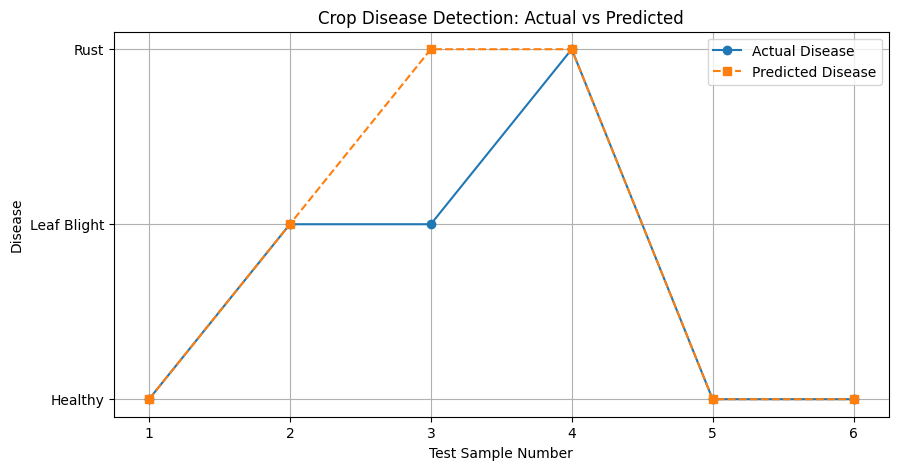

In [10]:
# Convert disease codes for plotting

actual_numeric = y_test.values
predicted_numeric = y_pred

# Create graph

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(actual_numeric) + 1),
    actual_numeric,
    marker="o",
    label="Actual Disease"
)

plt.plot(
    range(1, len(predicted_numeric) + 1),
    predicted_numeric,
    marker="s",
    linestyle="--",
    label="Predicted Disease"
)

plt.yticks(
    [0, 1, 2],
    ["Healthy", "Leaf Blight", "Rust"]
)

plt.xlabel("Test Sample Number")
plt.ylabel("Disease")
plt.title("Crop Disease Detection: Actual vs Predicted")

plt.grid(True)
plt.legend()
plt.show()

In [11]:
# New crop sample

new_crop = pd.DataFrame({
    "Leaf_Spot": [3],
    "Leaf_Yellowing": [3],
    "Leaf_Damage": [70],
    "Temperature": [31],
    "Moisture": [85]
})

# Predict disease

new_prediction = model.predict(new_crop)

predicted_disease = disease_names[new_prediction[0]]

print("New Crop Details:")
print(new_crop)

print("\nPredicted Crop Disease:", predicted_disease)

New Crop Details:
   Leaf_Spot  Leaf_Yellowing  Leaf_Damage  Temperature  Moisture
0          3               3           70           31        85

Predicted Crop Disease: Leaf Blight
